In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from utils.skeletonPATS import SkeletonPATS
from pats.utils import load_multiple_samples, get_speaker_intervals, get_all_missing_intervals
import numpy as np
from typing import List, Union
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
class SkeletonDataset(Dataset):
    def __init__(self, speakers :Union[List[str], str] ="fallon", split="train"):
        """
        data: tensor (N, 52, 2) o numpy array equivalente
        """
        skeleton_poses = []
        self.speakers = list(speakers) if isinstance(speakers, str) else speakers
        for speaker in self.speakers:
            intervals = get_speaker_intervals(speaker=speaker, split=split)
        
            clips = load_multiple_samples(
                speaker=speaker, 
                interval_ids=intervals
            )
            for clip in clips:
                pose = clip['pose']  # (N, 52, 2)
                pose[:,0] = [0.0, 0.0]
                skeleton_poses.append(pose)

        skeleton_poses = np.concatenate(skeleton_poses, axis=0)
        skeleton_poses = SkeletonPATS.normalize_skeleton(skeleton_poses)

        skeleton_poses = torch.tensor(skeleton_poses, dtype=torch.float32)
        self.data = skeleton_poses



    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]
        


In [3]:
dataset = SkeletonDataset(speakers=["fallon", "seth", "shelly"], split="dev")
print(f"{len(dataset)} samples loaded.")

193769 samples loaded.


In [4]:
# fallon = SkeletonDataset(speakers=["fallon"], split="dev")
# seth = SkeletonDataset(speakers=["seth"], split="dev")
# shelly = SkeletonDataset(speakers=["shelly"], split="dev")

# print(f"Fallon: {len(fallon)} samples loaded.")
# print(f"Seth: {len(seth)} samples loaded.")
# print(f"Shelly: {len(shelly)} samples loaded.")

In [5]:
import torch
import torch.nn as nn
from vector_quantize_pytorch import VectorQuantize

class MLPBlock(nn.Module):
    def __init__(self, dim_in, dim_out, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.LayerNorm(dim_out),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.block(x)


class SkeletonVQVAE(nn.Module):
    def __init__(
        self,
        encoder_dims=[104, 128, 64, 32],
        decoder_dims=[32, 64, 128, 104],
        num_codes=50,
        dropout=0.2,
        commitment_weight=0.1,
        decay=0.95,
        threshold_ema_dead_code=10
    ):
        super().__init__()

        # ------- ENCODER -------
        enc_layers = []
        for i in range(len(encoder_dims) - 1):
            enc_layers.append(
                MLPBlock(encoder_dims[i], encoder_dims[i+1], dropout)
            )
        self.encoder = nn.Sequential(*enc_layers)

        latent_dim = encoder_dims[-1]

        # ------- VQ -------
        self.vq = VectorQuantize(
            dim = latent_dim,
            codebook_size = num_codes,
            decay = decay,
            commitment_weight = commitment_weight,
            kmeans_init = True,
            threshold_ema_dead_code = threshold_ema_dead_code,
            orthogonal_reg_weight=1,
            orthogonal_reg_active_codes_only=False,
            orthogonal_reg_max_codes=num_codes
        )

        # ------- DECODER -------
        dec_layers = []
        for i in range(len(decoder_dims) - 1):
            dec_layers.append(
                nn.Sequential(
                    nn.Linear(decoder_dims[i], decoder_dims[i+1]),
                    nn.ReLU() if i < len(decoder_dims) - 2 else nn.Identity()
                )
            )

        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        # x: (B, 52, 2)
        x = x.view(x.size(0), -1)

        z = self.encoder(x)

        z_q, indices, vq_loss = self.vq(z)

        x_recon = self.decoder(z_q)
        x_recon = x_recon.view(-1, 52, 2)

        return x_recon, vq_loss, indices


In [6]:
from torch.utils.data import DataLoader, random_split

# 1. Carica il dataset dallo split 'dev'

# 2. Calcola le dimensioni per la suddivisione 80/20
total_len = len(dataset)
train_size = int(0.8 * total_len)
val_size = total_len - train_size

# 3. Suddividi in train e valid
train_dataset, val_dataset = random_split(
    dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) # Seed per consistenza
)

# 4. Crea i DataLoader
# Per il training attiviamo lo shuffle
train_loader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True, 
    drop_last=True
)

# Per la validazione shuffle=False
val_loader = DataLoader(
    val_dataset, 
    batch_size=64, 
    shuffle=False, 
    drop_last=False
)

print(f"Dataset 'dev' caricato e suddiviso:")
print(f" - Training frames (80%): {len(train_dataset)}")
print(f" - Validation frames (20%): {len(val_dataset)}")

Dataset 'dev' caricato e suddiviso:
 - Training frames (80%): 155015
 - Validation frames (20%): 38754


In [7]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm

def run_training(model, train_loader, val_loader, epochs=100, patience=15):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    recon_criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    # Dizionario per salvare la storia
    history = {'train_loss': [], 'val_loss': [], 'lr': [], 'train_recon_loss': [], 'train_vq_loss': [], 'skeleton_div_loss': [], 'train_perplexity': []}
    
    best_val_loss = float('inf')
    epochs_no_improve = 0 
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_recon, train_vq = 0.0, 0.0
        total_perplexity = 0.0
        
        current_lr = optimizer.param_groups[0]['lr']
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [LR: {current_lr:.2e}]")
        
        for batch in pbar:
            batch = batch.to(device)
            optimizer.zero_grad()
            x_recon, vq_loss, indices = model(batch)

            # --- CALCOLO PERPLEXITY ---
            # 1. Conta quante volte appare ogni indice
            # indices shape: (B)
            codebook_size = model.vq.codebook_size
            avg_probs = torch.histc(indices.float(), bins=codebook_size, min=0, max=codebook_size-1) 
            avg_probs = avg_probs / avg_probs.sum()
            
            # 2. Calcola l'entropia e la perplexity
            # Perplexity = exp(-sum(p * log(p)))
            perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
            total_perplexity += perplexity.item()

            recon_loss = recon_criterion(x_recon, batch)
            total_loss = recon_loss + vq_loss
            total_loss.backward()
            optimizer.step()
            
            train_recon += recon_loss.item() * batch.size(0)
            train_vq += vq_loss.item() * batch.size(0)
            pbar.set_postfix(loss=total_loss.item())

        model.eval()
        val_recon, val_vq = 0.0, 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                x_recon, vq_loss, _ = model(batch)
                recon_loss = recon_criterion(x_recon, batch)
                val_recon += recon_loss.item() * batch.size(0)
                val_vq += vq_loss.item() * batch.size(0)

        avg_train = (train_recon + train_vq) / len(train_loader.dataset)
        avg_val = (val_recon + val_vq) / len(val_loader.dataset)
        avg_train_recon = train_recon / len(train_loader.dataset)
        avg_train_vq = train_vq / len(train_loader.dataset)
        avg_train_perplexity = total_perplexity / len(train_loader)

        # Salvataggio nella history
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['lr'].append(current_lr)
        history['train_recon_loss'].append(avg_train_recon)
        history['train_vq_loss'].append(avg_train_vq)
        history['train_perplexity'].append(avg_train_perplexity)

        print(f"Summary -> Train: {avg_train:.6f} | Val: {avg_val:.6f}")
        scheduler.step(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\n[STOP] Early stopping at epoch {epoch}")
                break
                
    return history # Restituisce i dati per il plot

# Avvio
model = SkeletonVQVAE(num_codes=64, threshold_ema_dead_code=20, commitment_weight=0.15, dropout=0.2, encoder_dims=[104, 64, 64, 32], decoder_dims=[32, 64, 64, 104])
history = run_training(model, train_loader, val_loader, patience=15)

Epoch 1/100 [LR: 1.00e-04]: 100%|██████████| 2422/2422 [00:40<00:00, 60.07it/s, loss=0.309]


Summary -> Train: 0.469962 | Val: 0.080794


Epoch 2/100 [LR: 1.00e-04]: 100%|██████████| 2422/2422 [00:40<00:00, 59.83it/s, loss=0.235]


Summary -> Train: 0.264832 | Val: 0.063895


Epoch 3/100 [LR: 1.00e-04]: 100%|██████████| 2422/2422 [00:52<00:00, 46.28it/s, loss=0.237]


...

Summary -> Train: 0.219881 | Val: 0.055519


Epoch 38/100 [LR: 6.25e-06]: 100%|██████████| 2422/2422 [01:01<00:00, 39.62it/s, loss=0.197]


Summary -> Train: 0.219986 | Val: 0.053901


Epoch 39/100 [LR: 6.25e-06]: 100%|██████████| 2422/2422 [00:58<00:00, 41.33it/s, loss=0.212]


Summary -> Train: 0.219693 | Val: 0.055349

[STOP] Early stopping at epoch 39


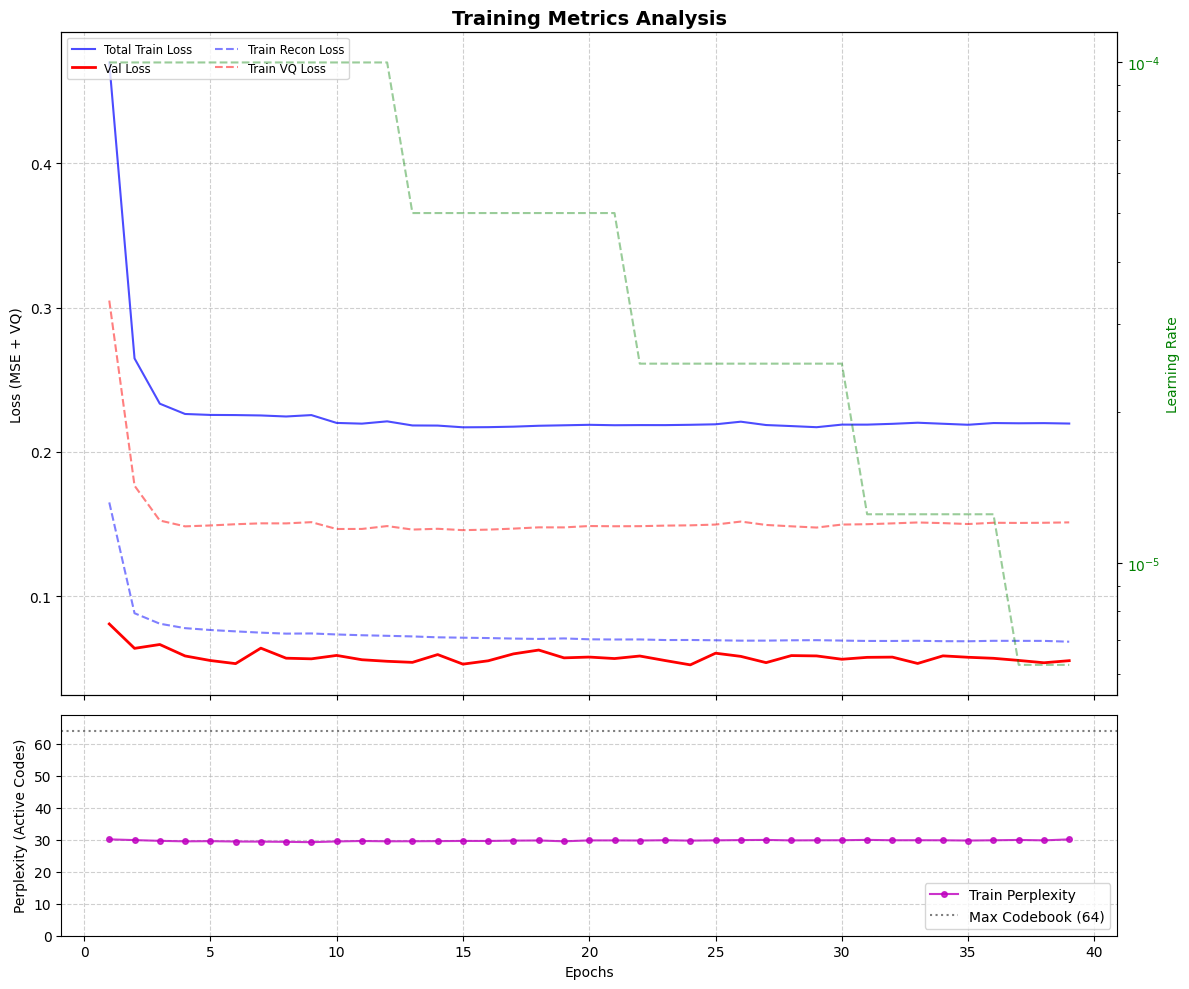

In [8]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Creiamo due subplot: uno sopra l'altro
    fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # --- SUBPLOT 1: LOSS & LEARNING RATE ---
    ax1.plot(epochs, history['train_loss'], 'b-', label='Total Train Loss', alpha=0.7)
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.plot(epochs, history['train_recon_loss'], 'b--', label='Train Recon Loss', alpha=0.5)
    ax1.plot(epochs, history['train_vq_loss'], 'r--', label='Train VQ Loss', alpha=0.5)

    ax1.set_ylabel('Loss (MSE + VQ)')
    ax1.legend(loc='upper left', fontsize='small', ncol=2)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.set_title('Training Metrics Analysis', fontweight='bold', fontsize=14)

    # Learning Rate sul secondo asse del primo plot
    ax2 = ax1.twinx() 
    ax2.plot(epochs, history['lr'], 'g--', label='Learning Rate', alpha=0.4)
    ax2.set_ylabel('Learning Rate', color='g')
    ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelcolor='g')

    # --- SUBPLOT 2: PERPLEXITY ---
    ax3.plot(epochs, history['train_perplexity'], 'm-o', markersize=4, label='Train Perplexity', alpha=0.8)
    
    # Linea orizzontale per il target massimo (32 codici)
    target_p = model.vq.codebook_size
    ax3.axhline(y=target_p, color='k', linestyle=':', alpha=0.5, label=f'Max Codebook ({target_p})')
    
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('Perplexity (Active Codes)')
    ax3.set_ylim(0, target_p + 5) # Scala fissa per vedere quanto siamo vicini al massimo
    ax3.legend(loc='lower right')
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_training_history(history)


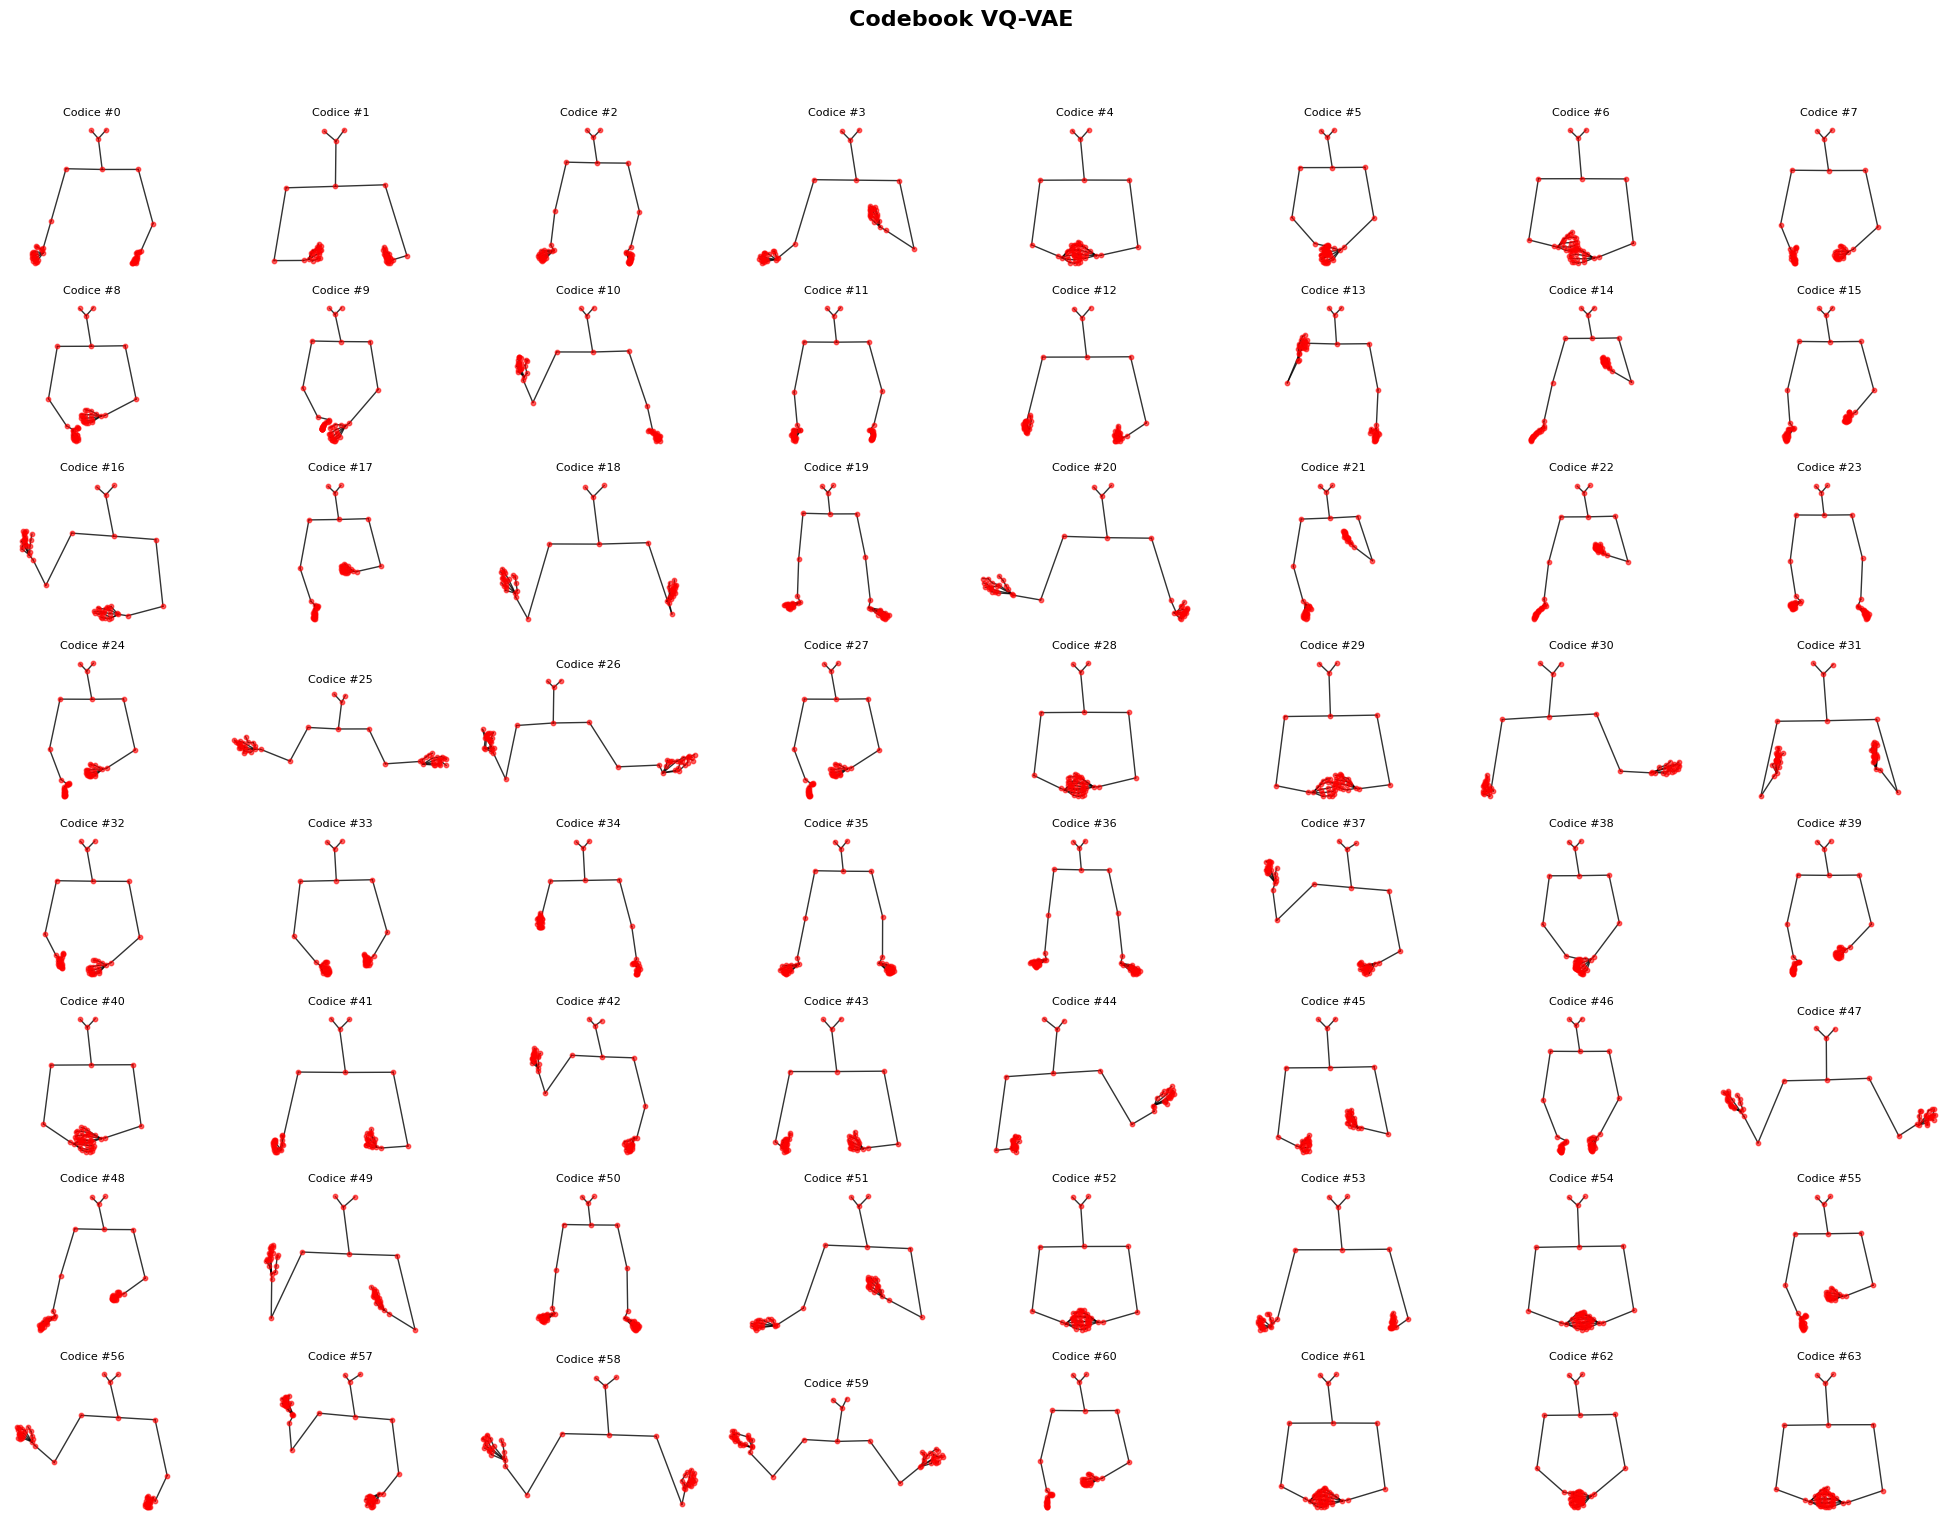

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_decoded_codebook_skeletons(model, num_rows=4, num_cols=8, figsize=(15, 8)):
    """
    Decodifica una selezione di elementi dal codebook del VQ-VAE e li visualizza come scheletri.
    Se il codebook contiene meno elementi delle celle nella griglia, le celle rimanenti vengono lasciate vuote.
    """
    model.eval()
    parents = SkeletonPATS.parents()  # Assicurati che SkeletonPATS sia importato
    
    with torch.no_grad():
        # Recupero vettori dal codebook
        if hasattr(model.vq, 'codebook'):
            codebook_embeddings = model.vq.codebook
        else:
            codebook_embeddings = model.vq.embedding.weight 
        
        # Decodifica
        decoded_latent = model.decoder(codebook_embeddings)
        decoded_skeletons = decoded_latent.view(-1, 52, 2).cpu().numpy()

    # Numero totale di slot nella griglia
    total_slots = num_rows * num_cols
    num_codes = len(decoded_skeletons)

    # Indici sicuri da plottare
    indices_to_plot = np.arange(min(total_slots, num_codes))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    fig.suptitle('Codebook VQ-VAE', fontsize=16, fontweight='bold')

    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for i, ax in enumerate(axes):
        if i < len(indices_to_plot):
            idx = indices_to_plot[i]
            frame = decoded_skeletons[idx]

            # Disegno ossa
            for j, parent_idx in enumerate(parents):
                if parent_idx >= 0:
                    ax.plot(
                        [frame[j, 0], frame[parent_idx, 0]],
                        [frame[j, 1], frame[parent_idx, 1]],
                        'k-', linewidth=1, alpha=0.8
                    )
            
            # Disegno giunti
            ax.scatter(frame[:, 0], frame[:, 1], c='red', s=10, alpha=0.6, zorder=5)

            ax.set_title(f"Codice #{idx}", fontsize=8)
            ax.set_aspect('equal', adjustable='box')
            ax.axis('off')
            ax.invert_yaxis()
        else:
            ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

num_cols = 8
num_rows = model.vq.codebook_size // num_cols + (1 if model.vq.codebook_size % num_cols != 0 else 0)
plot_decoded_codebook_skeletons(model, num_rows=num_rows, num_cols=num_cols, figsize=(20, 2*num_rows))

In [ ]:
import numpy as np

def compare_quantized_animation(model, speaker='fallon', clip_idx=30, interval=50, smooth_factor=0.5):
    model.eval()
    device = next(model.parameters()).device

    # 1. Caricamento e Normalizzazione (Tuo codice invariato)
    intervals = get_speaker_intervals(speaker=speaker, split="train")
    clips = load_multiple_samples(speaker=speaker, interval_ids=intervals[clip_idx:clip_idx+1])
    if not clips: return "Clip non trovata"

    raw_pose = clips[0]['pose']
    raw_pose[:, 0] = [0.0, 0.0]
    normalized_pose = SkeletonPATS.normalize_skeleton(raw_pose)
    parents = SkeletonPATS.parents()

    # 2. Generazione versione Quantizzata
    input_tensor = torch.tensor(normalized_pose, dtype=torch.float32).to(device)
    with torch.no_grad():
        x_recon, _, _ = model(input_tensor) 
        quantized_pose = x_recon.view(-1, 52, 2).cpu().numpy()

    # --- AGGIUNTA: INTERPOLAZIONE LINEARE (SMOOTHING) ---
    # Creiamo una copia per non sovrascrivere
    smoothed_pose = np.copy(quantized_pose)
    # Partiamo dal secondo frame e mediamo con il precedente
    for t in range(1, len(smoothed_pose)):
        smoothed_pose[t] = (1 - smooth_factor) * quantized_pose[t] + smooth_factor * smoothed_pose[t-1]
    # ----------------------------------------------------

    # 3. Setup della Figura (Subplot 2 ora usa smoothed_pose)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    for ax, title in zip([ax1, ax2], ['Original', f'Quantized + Smooth ({smooth_factor}) VQ-VAE']):
        ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
        ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
        ax.set_title(title)

    lines1 = [ax1.plot([], [], 'k-', linewidth=2, alpha=0.8)[0] for _ in range(len(parents))]
    scatter1 = ax1.scatter([], [], c='blue', s=20)
    lines2 = [ax2.plot([], [], 'r-', linewidth=2, alpha=0.8)[0] for _ in range(len(parents))]
    scatter2 = ax2.scatter([], [], c='darkred', s=20)

    def update(frame_idx):
        f1 = normalized_pose[frame_idx]
        f2 = smoothed_pose[frame_idx] # Usiamo la versione interpolata
        for i, p_idx in enumerate(parents):
            if p_idx >= 0:
                lines1[i].set_data([f1[i,0], f1[p_idx,0]], [f1[i,1], f1[p_idx,1]])
                lines2[i].set_data([f2[i,0], f2[p_idx,0]], [f2[i,1], f2[p_idx,1]])
        scatter1.set_offsets(f1); scatter2.set_offsets(f2)
        return lines1 + lines2 + [scatter1, scatter2]

    anim = FuncAnimation(fig, update, frames=len(normalized_pose), blit=True, interval=interval)
    plt.close()
    return HTML(anim.to_html5_video())


In [14]:
# Esecuzione (passa il tuo oggetto modello caricato)
compare_quantized_animation(model, speaker='fallon', clip_idx=25)

In [19]:
compare_quantized_animation(model, speaker='seth', clip_idx=15)



In [17]:
compare_quantized_animation(model, speaker='shelly', clip_idx=18)